In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split

In [10]:
df=pd.read_csv('Lab 21 House_Rent_Dataset.csv')
df.head()
               

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [11]:
df.shape

(4746, 12)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [13]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


<Axes: >

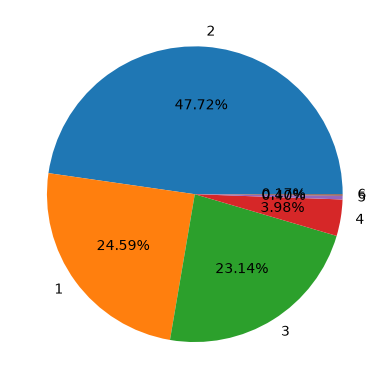

In [16]:
df['BHK'].value_counts().plot(kind='pie',autopct='%1.2f%%')

In [18]:
df['BHK'].value_counts().sort_values()

BHK
6       8
5      19
4     189
3    1098
1    1167
2    2265
Name: count, dtype: int64

In [19]:
df['City'].unique()

<StringArray>
['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad']
Length: 6, dtype: str

In [20]:
df['Point of Contact'].unique()

<StringArray>
['Contact Owner', 'Contact Agent', 'Contact Builder']
Length: 3, dtype: str

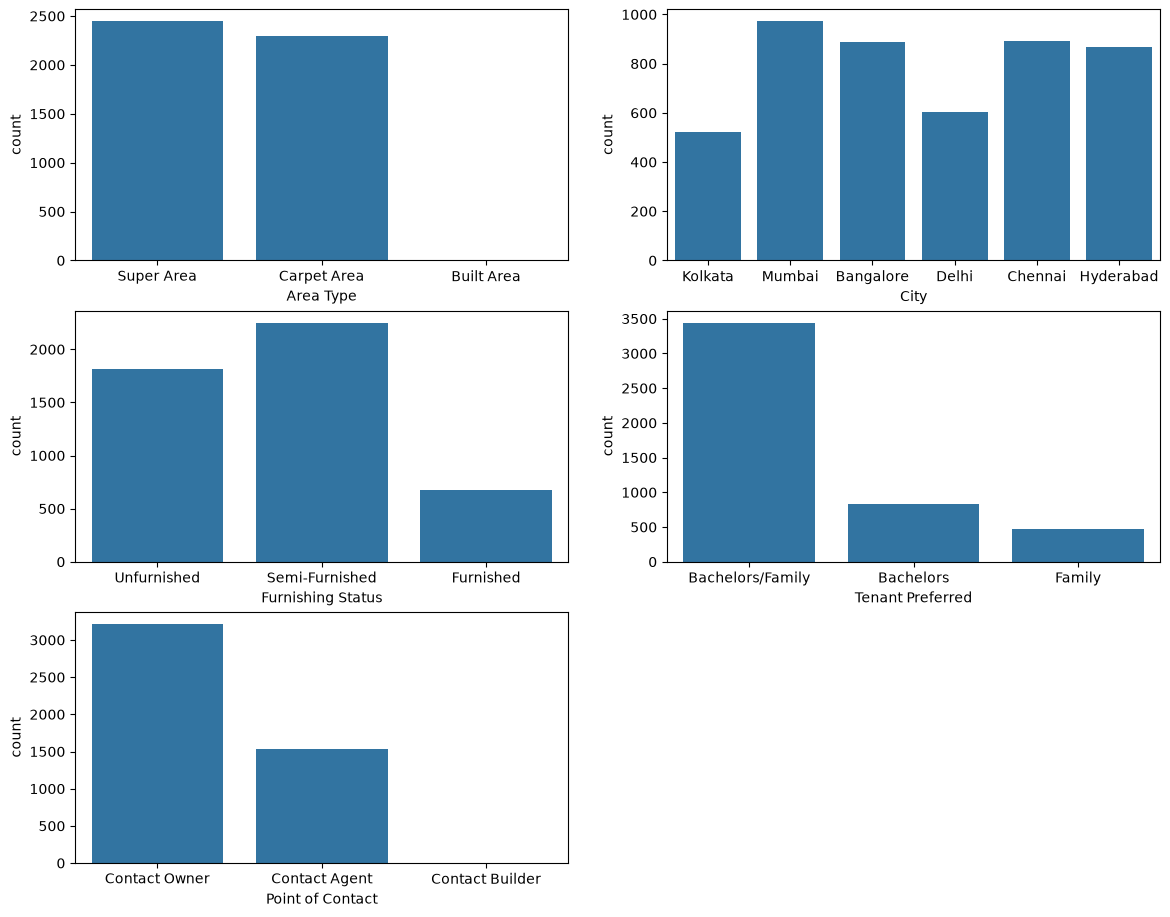

In [26]:
plt.figure(figsize=(14, 15))
for i, col in enumerate(["Area Type", "City", "Furnishing Status","Tenant Preferred", "Point of Contact"]): 
    plt.subplot(4,2,i+1)
    sns.countplot(data=df,x=col)

In [29]:
!pip install category-encoders

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 1.6 MB/s eta 0:00:07
   -------- ------------------------------- 2.4/11.3 MB 2.9 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/11.3 MB 3.5 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 3.6 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 7.3/11.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 4.0 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\SSBhat\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Text(0.5, 1.0, 'Relation between rent and BHK by city')

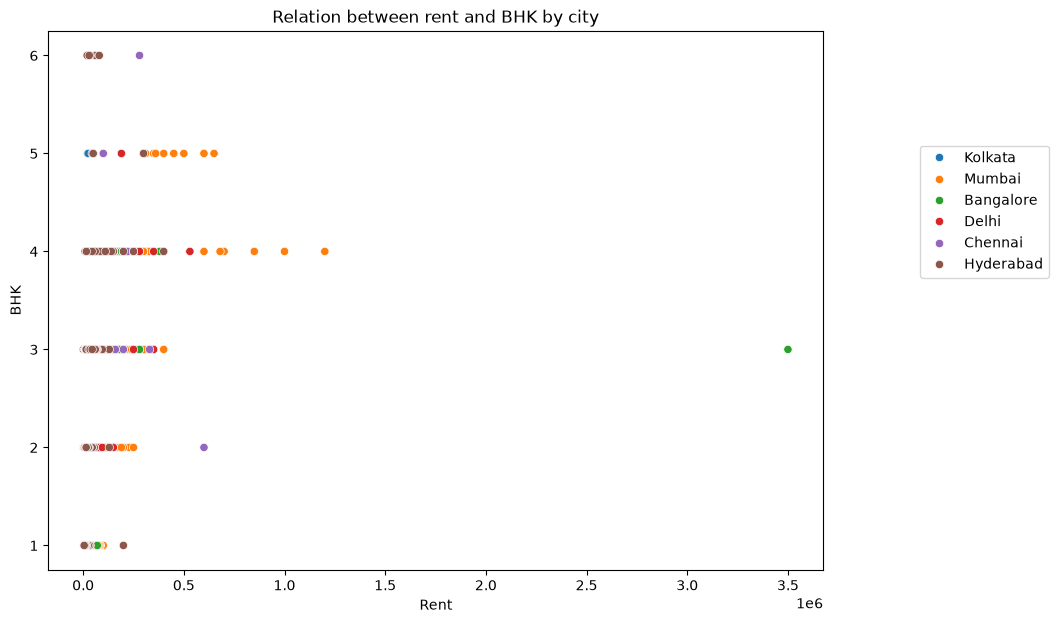

In [32]:
plt.figure(figsize=(10,7))
sns.scatterplot(x="Rent", y="BHK", data=df, hue="City")
plt.legend(bbox_to_anchor=(1.3,0.8))
plt.title("Relation between rent and BHK by city")

<Axes: xlabel='Rent', ylabel='Size'>

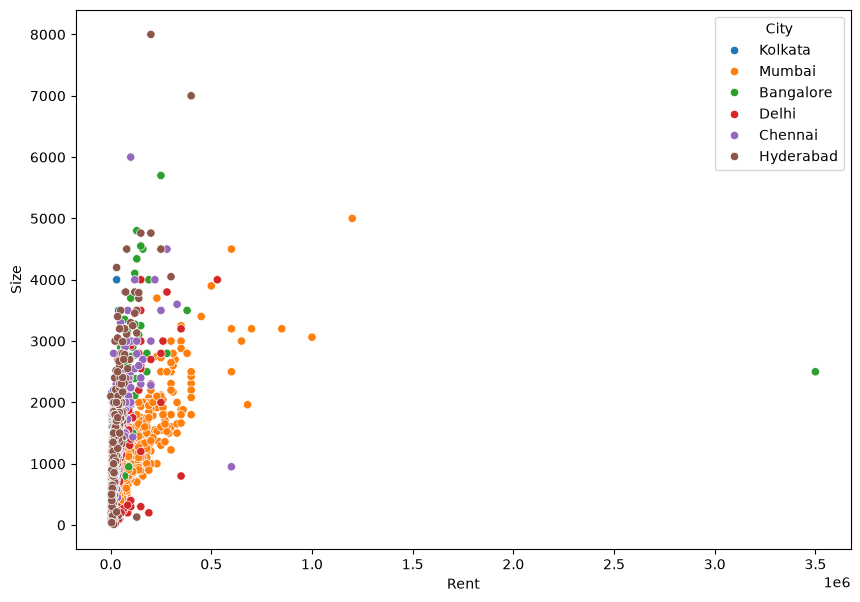

In [33]:
plt. figure(figsize=(10,7))
sns.scatterplot(data=df, x="Rent", y="Size", hue="City")

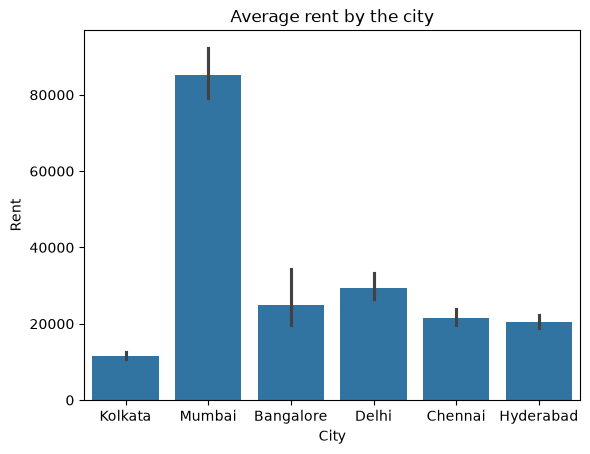

In [35]:
sns.barplot(data=df, x="City", y="Rent")
plt.title("Average rent by the city")
plt.show()

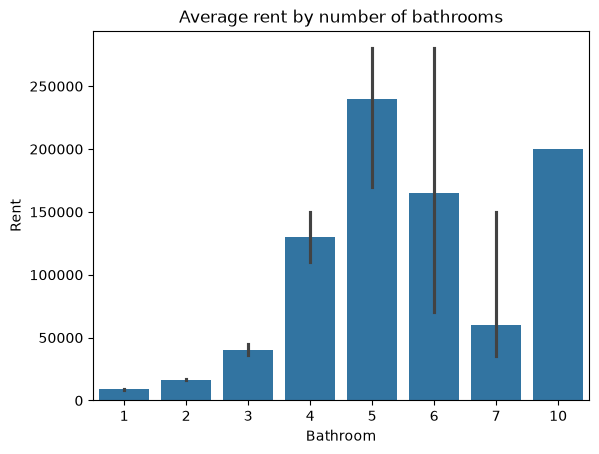

In [36]:
sns.barplot(data=df, x="Bathroom", y="Rent", estimator=np.median)
plt.title("Average rent by number of bathrooms")
plt.show()

In [38]:
x=df.drop(columns='Rent')
y=df['Rent']

In [42]:
import category_encoders as ce
enc=ce.LeaveOneOutEncoder(return_df=True)
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [43]:
x=enc.fit_transform(x,y)
x.head()

,Posted On,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,49986.301370,2,1100,14164.719198,18676.943967,6500.000000,11648.319312,22468.505513,31216.953238,2,16706.291757
1,33369.521739,2,800,17947.602740,18672.853988,3500.000000,11629.198853,38727.130222,31214.048795,1,16703.181337
2,22156.603774,2,1000,17957.876712,18674.080982,23600.000000,11634.934990,38728.463556,31214.920128,1,16704.114463
3,36085.321101,2,800,14458.465608,18676.943967,22000.000000,11648.319312,22468.505513,31216.953238,1,16706.291757
4,15857.142857,2,850,14465.079365,52405.438398,34993.451327,11653.099426,22469.883682,42185.583836,1,16707.069362


In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [47]:
x=scaler.fit_transform(x)
x_df=pd.DataFrame(x)
x_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.455100,0.2,0.136421,0.011747,0.273162,0.005055,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.270592,0.2,0.098874,0.017362,0.273074,0.001685,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.146087,0.2,0.123905,0.017377,0.273100,0.024264,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.300748,0.2,0.098874,0.012183,0.273162,0.022466,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.076140,0.2,0.105131,0.012193,0.999941,0.037062,0.004452,0.009593,0.587919,0.000000,0.003233


In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [56]:
x_train, x_test, y_train, y_test=train_test_split(x,y,train_size=0.8,random_state=42)
x_train.shape,x_test.shape


((3796, 11), (950, 11))

In [57]:
#classification model

In [65]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [66]:
wdf=pd.read_csv('Lab 22 winequality-red.csv')
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [68]:
wdf['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [69]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [72]:
x=wdf.drop(columns='quality')
y=wdf['quality']

In [73]:
x.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

In [74]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64>

In [75]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\SSBhat\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [79]:
from imblearn.over_sampling import SMOTE
oversample=SMOTE(k_neighbors=4)

In [81]:
x,y=oversample.fit_resample(x.fillna(0),y)
y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [83]:
xtr,xte,ytr,yte=train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
#log reg
lgr=LogisticRegression()
lgr.fit(xtr,ytr)
lgr_pred=lgr.predict(xte)
lgr_pred

C:\Users\SSBhat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([3, 5, 7, 6, 6, 4, 6, 3, 5, 5, 7, 7, 5, 3, 7, 6, 4, 4, 7, 5, 6, 3,
       5, 3, 4, 3, 7, 3, 6, 8, 3, 3, 8, 8, 3, 4, 6, 8, 3, 7, 8, 8, 5, 7,
       7, 4, 7, 3, 3, 8, 6, 8, 7, 6, 6, 3, 4, 6, 5, 3, 4, 4, 3, 3, 7, 4,
       3, 8, 3, 7, 4, 4, 5, 3, 5, 5, 4, 4, 7, 3, 8, 8, 6, 6, 5, 7, 8, 3,
       7, 5, 3, 6, 6, 3, 4, 3, 4, 7, 8, 7, 3, 8, 3, 5, 5, 5, 8, 3, 8, 8,
       3, 4, 8, 5, 6, 6, 3, 8, 3, 5, 5, 5, 7, 5, 4, 7, 7, 3, 3, 3, 8, 3,
       4, 4, 5, 3, 8, 6, 4, 3, 8, 5, 4, 3, 7, 8, 8, 6, 8, 4, 4, 5, 5, 5,
       5, 5, 4, 7, 8, 8, 4, 3, 7, 6, 7, 3, 7, 6, 5, 4, 4, 8, 6, 4, 8, 7,
       4, 3, 7, 5, 3, 3, 8, 7, 5, 6, 3, 8, 6, 8, 8, 5, 6, 7, 6, 3, 5, 3,
       4, 8, 6, 8, 4, 5, 3, 6, 4, 5, 3, 3, 8, 8, 6, 5, 6, 6, 5, 3, 8, 3,
       5, 3, 8, 7, 8, 4, 5, 3, 6, 8, 8, 4, 8, 4, 5, 5, 7, 7, 3, 3, 3, 8,
       3, 4, 4, 6, 8, 8, 8, 8, 3, 7, 8, 8, 4, 7, 4, 4, 5, 3, 3, 8, 3, 8,
       7, 4, 6, 7, 8, 4, 7, 4, 3, 8, 4, 6, 4, 8, 5, 8, 5, 8, 5, 6, 5, 5,
       3, 4, 4, 8, 8, 3, 4, 5, 8, 3, 3, 5, 7, 5, 4,

In [89]:
acc=accuracy_score(yte,lgr_pred)
acc*100

46.69926650366748

In [94]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(yte,lgr_pred)
cm

array([[95, 25, 12,  0,  0,  0],
       [28, 62, 31,  7,  0,  3],
       [28, 28, 64, 20,  6,  4],
       [24, 34, 21, 38, 13, 25],
       [ 7,  4,  3, 26, 37, 39],
       [ 0,  0,  0,  1, 47, 86]])

In [95]:
cr=classification_report(yte,lgr_pred)
print(cr)

              precision    recall  f1-score   support

           3       0.52      0.72      0.61       132
           4       0.41      0.47      0.44       131
           5       0.49      0.43      0.46       150
           6       0.41      0.25      0.31       155
           7       0.36      0.32      0.34       116
           8       0.55      0.64      0.59       134

    accuracy                           0.47       818
   macro avg       0.46      0.47      0.46       818
weighted avg       0.46      0.47      0.45       818

